In [1]:
import numpy
import skimage.io as skio
import matplotlib.pyplot as plt
import h5py
import hdf5plugin  # needed to decompress bs-lz4 compressed dataset 
# hdf5plugin can be installed by "pip install hdf5plugin"

In [2]:
fname = "/local/MQICHU/xpcs_edge_computing_datasets/eiger4m/D0131_US-Cup2_a0010_f005000_r00001/D0131_US-Cup2_a0010_f005000_r00001.h5"

In [3]:
with h5py.File(fname, "r") as f:
    dset = f["/entry/data/data"]

    print("number of frames:", dset.shape[0])
    print("frame shape", dset.shape[1:])

number of frames: 5000
frame shape (2162, 2068)


In [4]:
# reading data must be done within the context
# this will yield error becase dset no long has access to the raw data
# print(dset[0])

In [5]:
# example of travese the data
with h5py.File(fname, "r") as f:
    dset = f["/entry/data/data"]
    frame_sum = 0
    for idx in range(dset.shape[0]):
        frame = dset[idx]
        frame_sum += frame

In [6]:
# alternatively, read everything in RAM. It will take LOTs of RAM
# with h5py.File(fname, "r") as f:
#     dset = f["/entry/data/data"][()]
# print(dset[0])
# frame_sum = np.sum(dset, axis=0)

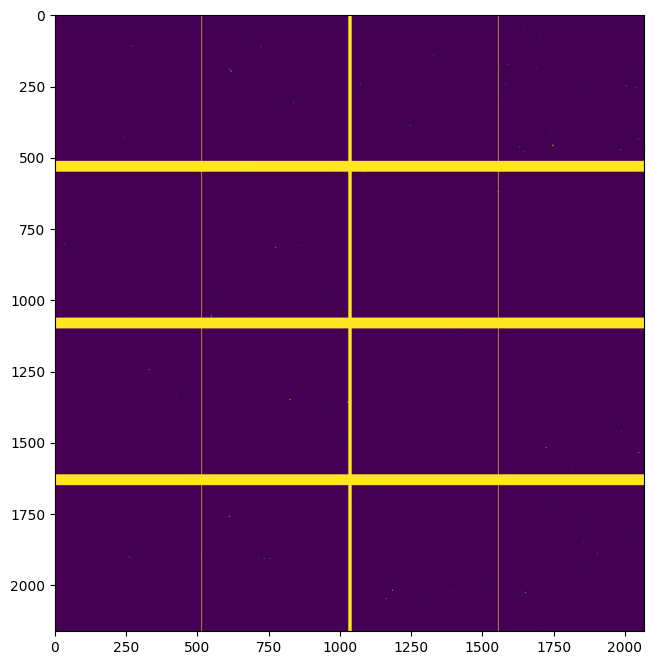

In [7]:
# plot the raw data in linear scale
# this will not likely to be useful because the invalid pixels (gaps and bad pixels)
plt.imshow(frame_sum)

In [8]:
# ask your beamline scientist which blemish file to use
# the blemish file contains the invalid pixels on the detector
mask = skio.imread("../blemish_files/8idEiger4m/latest_blemish.tif")

In [9]:
# apply mask to the frames
frame_sum *= mask

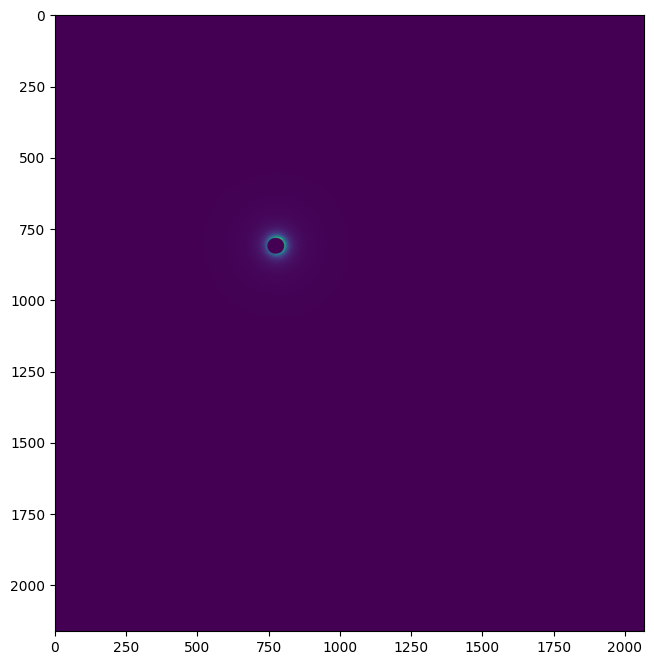

In [10]:
# linear scale
plt.imshow(frame_sum)

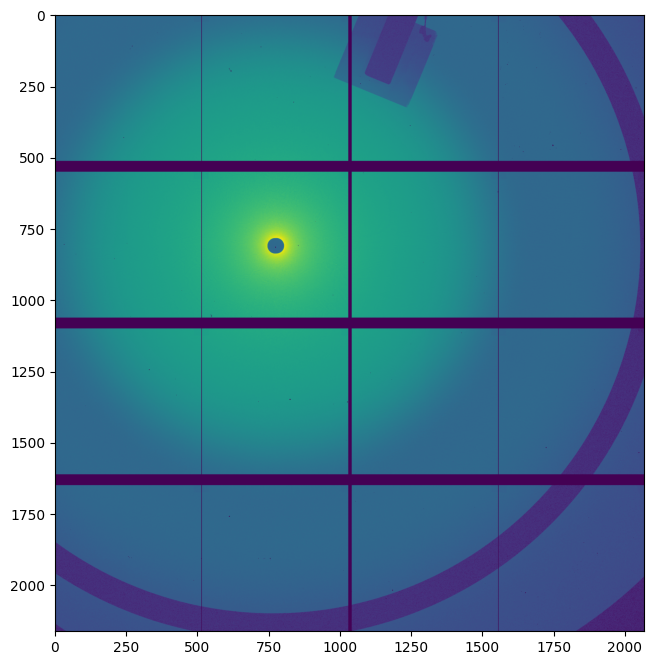

In [11]:
# log scale
plt.imshow(np.log10(frame_sum + 1))